Q1.ans:  Series is a  1D labeled array that holds a single column of data.
DataFrame is a 2D labeled data structure (like a table) that holds multiple columns.

Q2.ans:head(): Returns the first \(n\) rows (default is 5) to preview the data.
info(): Displays data types,memory usage, and missing values.
describe(): It generates summary statistics (mean, median, min, max) for numerical columns.
value_counts(): Counts the frequency of unique values in a single column.

Q3.ans:.loc[]: It Selects data using label-based indexing (explicit row names or column titles).
.iloc[]: It Selects data using integer-based indexing (numerical row/column positions starting from 0).

Q4.ans:a. I would use distribution of Age beacuse it has Groups of continuous numerical data which it sends into bins to reveal shape, spread, and skewness.

Q5.ans:Overfitting: The model learns training data too perfectly, including noise, causing poor performance on new data.
Underfitting: The model is too simple to learn the underlying patterns, performing poorly on both training and test data.

Q6.ans:Fit: It learns or calculate parameters from training datas.It cant modify or transform data.
fit_transform:At first it uses fit to learn  about parameters then it transforms the data.

Q7.Linear Regression: Used to predict a continuous numerical value (e.g., Taxis data).
Logistic Regression: Used to predict a categorical outcome or probability (e.g., finding Spam or Not Spam).

In [23]:
#Q8.
import pandas as pd
from sklearn.datasets import load_iris


In [24]:
iris = load_iris()


In [25]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)


In [26]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [27]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [29]:
numerical_columns = df.select_dtypes(include=["number"])
categorical_columns = df.select_dtypes(include=["object", "category"])

In [30]:
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [31]:
numerical_columns.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [32]:
categorical_columns.head()

""
0
1
2
3
4


Task 2:

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

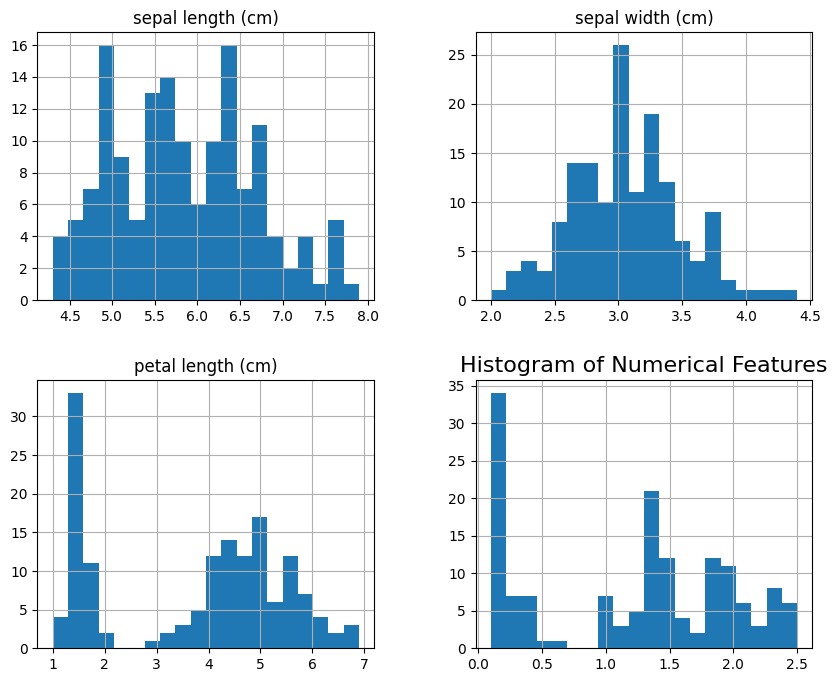

In [34]:
#Histogram of all numerical features.
df.hist(figsize=(10, 8), bins=20)

plt.title("Histogram of Numerical Features", fontsize=16)
plt.show()

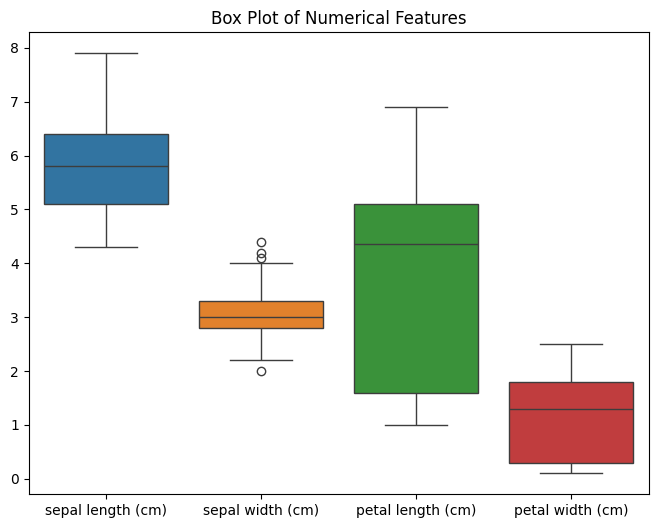

In [35]:
#Box plot for numerical columns.
plt.figure(figsize=(8, 6))

sns.boxplot(data=df.select_dtypes(include="number"))

plt.title("Box Plot of Numerical Features")
plt.show()

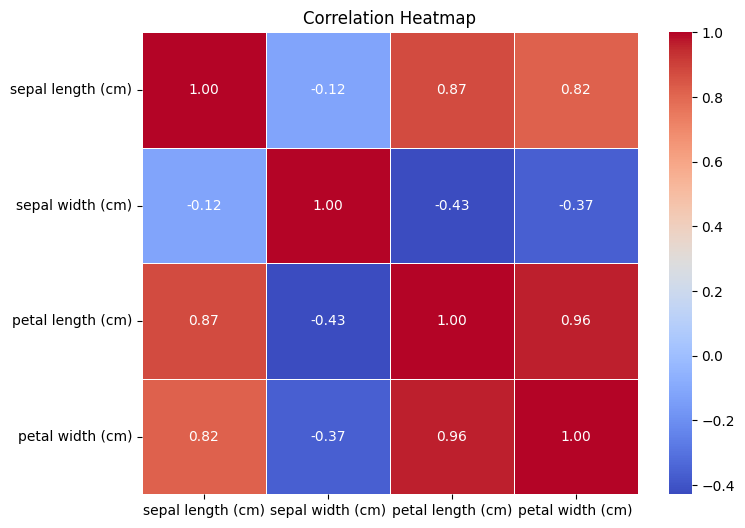

In [36]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

correlation = df.select_dtypes (include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

In [39]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

In [40]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [43]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

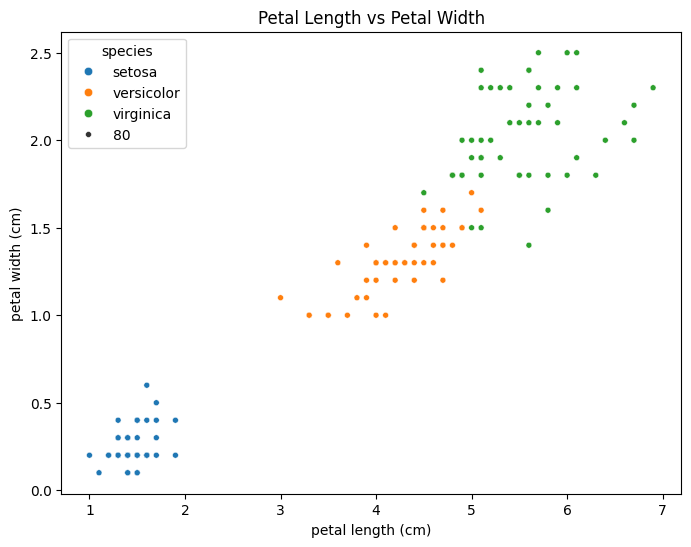

In [45]:
plt.figure(figsize=(8,6)) 
sns.scatterplot( data= df, x="petal length (cm)", y="petal width (cm)", hue="species", size= 80 )
plt.title("Petal Length vs Petal Width")
plt.show()

Observations
The histogram shows that the numerical features are distributed differently. Petal length and petal width have distinct groups, while sepal length and sepal width are more evenly distributed.
The box plots shows that most numerical features contain few or no significant outliers. The values are normaly well distributed, although sepal width may have a few mild outliers.
The correlation heatmap and scatter plot potrais a strong positive relationship between petal length and petal width. As petal length goes upwords, petal width also increases, making these features useful for distinguishing different Iris species.

task 3:

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [47]:

X = df.drop(columns=["petal length (cm)"])
X = pd.get_dummies(X, columns=["species"], drop_first=True)
y = df["petal length (cm)"]

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

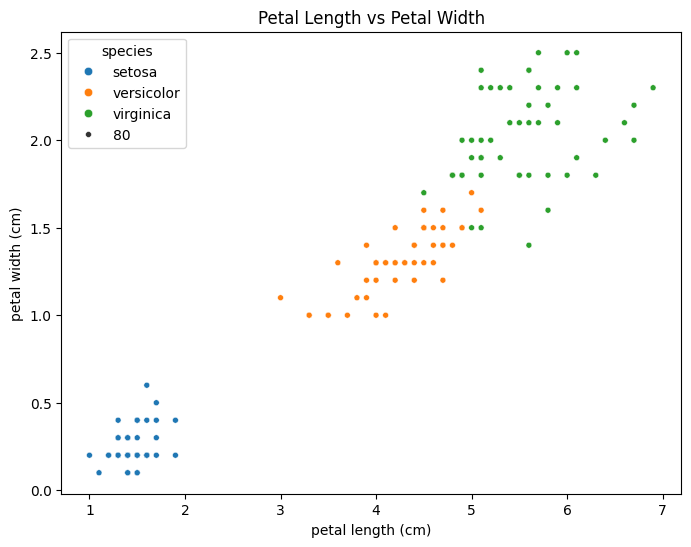

In [49]:
plt.figure(figsize=(8,6)) 
sns.scatterplot( data= df, x="petal length (cm)", y="petal width (cm)", hue="species", size= 80 )
plt.title("Petal Length vs Petal Width")
plt.show()

In [50]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

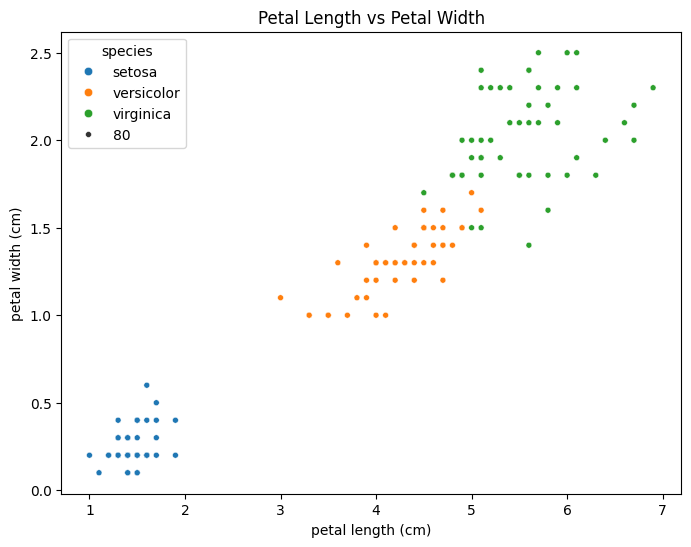

In [51]:
plt.figure(figsize=(8,6)) 
sns.scatterplot( data= df, x="petal length (cm)", y="petal width (cm)", hue="species", size= 80 )
plt.title("Petal Length vs Petal Width")
plt.show()

In [52]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

knn_prediction = knn.predict(X_test)

In [53]:
lr_mae = mean_absolute_error(y_test, lr_prediction)
lr_mse = mean_squared_error(y_test, lr_prediction)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_prediction)


In [54]:
knn_mae = mean_absolute_error(y_test, knn_prediction)
knn_mse = mean_squared_error(y_test, knn_prediction)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_prediction)


In [55]:
print("========== Linear Regression ==========")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

print("\n========== KNN Regressor ==========")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R2 Score:", knn_r2)

========== Linear Regression ==========
MAE : 0.22729146910143683
MSE : 0.08787176438628254
RMSE: 0.2964317196021413
R2 Score: 0.973188484075177

========== KNN Regressor ==========
MAE : 0.2373333333333333
MSE : 0.08511999999999992
RMSE: 0.29175332046096736
R2 Score: 0.9740281050294103


In [56]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Prediction": lr_prediction,
    "KNN Prediction": knn_prediction
})

comparison.head(10)

,Actual,Linear Prediction,KNN Prediction
0,4.7,4.264713,4.38
1,1.7,1.850131,1.44
2,6.9,6.448273,6.36
3,4.5,4.383796,4.52
4,4.8,4.802256,4.54
5,1.5,1.796703,1.54
6,3.6,4.021746,4.16
7,5.1,5.907748,5.62
8,4.5,4.602353,4.48
9,3.9,4.103729,4.12


In [57]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor"],
    "MAE": [lr_mae, knn_mae],
    "MSE": [lr_mse, knn_mse],
    "RMSE": [lr_rmse, knn_rmse],
    "R2 Score": [lr_r2, knn_r2]
})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.227291,0.087872,0.296432,0.973188
1,KNN Regressor,0.237333,0.085120,0.291753,0.974028


Task 4

In [61]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [62]:

X = df.drop(columns=["species"])
y = df["species"]

In [63]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [66]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_prediction = lr.predict(X_test)

In [67]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_prediction = knn.predict(X_test)

In [75]:
lr_accuracy = accuracy_score(y_test, lr_prediction)
lr_precision = precision_score(y_test, lr_prediction, average="weighted")
lr_recall = recall_score(y_test, lr_prediction, average="weighted")
lr_f1 = f1_score(y_test, lr_prediction, average="weighted")

print("Logistic Regression")

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613


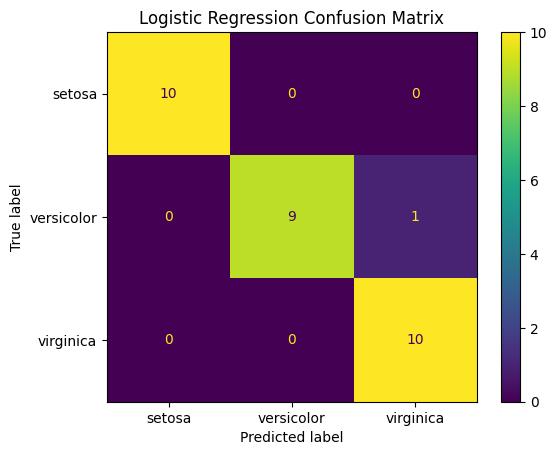

In [76]:
cm = confusion_matrix(y_test, lr_prediction)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [73]:
knn_accuracy = accuracy_score(y_test, knn_prediction)
knn_precision = precision_score(y_test, knn_prediction, average="weighted")
knn_recall = recall_score(y_test, knn_prediction, average="weighted")
knn_f1 = f1_score(y_test, knn_prediction, average="weighted")

print("KNN Classifier")

print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)

KNN Classifier
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [77]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN Classifier"],
    "Accuracy": [lr_accuracy, knn_accuracy],
    "Precision": [lr_precision, knn_precision],
    "Recall": [lr_recall, knn_recall],
    "F1 Score": [lr_f1, knn_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.966667,0.969697,0.966667,0.966583
1,KNN Classifier,1.000000,1.000000,1.000000,1.000000


The model with the higher Accuracy, Precision, Recall, and F1-score is considered the better-performing classifier. On the Iris dataset, KNN (with a suitable value of K) often performs slightly better because the classes are naturally clustered in feature space. However, your conclusion should match the metrics produced by your notebook.

In [78]:
accuracy_list = []

for k in range(1, 16):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    accuracy_list.append(accuracy)
results = pd.DataFrame({
    "K Value": range(1,16),
    "Accuracy": accuracy_list
})

results

,K Value,Accuracy
0,1,0.966667
1,2,0.933333
2,3,1.000000
3,4,1.000000
4,5,1.000000
5,6,0.966667
6,7,0.966667
7,8,0.966667
8,9,1.000000
9,10,1.000000


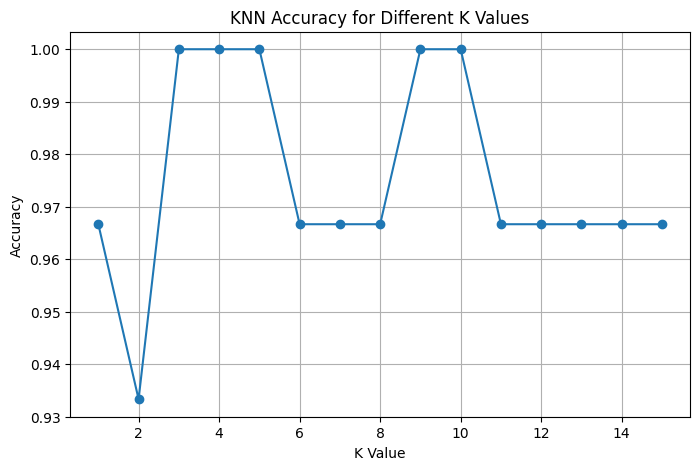

In [81]:
plt.figure(figsize=(8,5))

plt.plot(range(1,16), accuracy_list, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")

plt.title("KNN Accuracy for Different K Values")

plt.grid(True)

plt.show()